[ WARN:0@1407.716] global loadsave.cpp:275 findDecoder imread_('bimodal_gt.png'): can't open/read file: check file path/integrity
[ WARN:0@1407.716] global loadsave.cpp:275 findDecoder imread_('uneven_gt.png'): can't open/read file: check file path/integrity
[ WARN:0@1407.716] global loadsave.cpp:275 findDecoder imread_('overlap_gt.png'): can't open/read file: check file path/integrity



=== BIMODAL ===
Method | IoU | Dice | Acc | Prec | Recall
global       0.920 0.958 0.996 1.000 0.920
otsu         1.000 1.000 1.000 1.000 1.000
adapt_mean   0.038 0.072 0.087 0.038 0.778
adapt_gauss  0.040 0.078 0.072 0.041 0.853
sobel        0.190 0.319 0.818 0.192 0.928
canny_1      0.052 0.098 0.950 0.292 0.059
canny_2      0.045 0.086 0.953 0.377 0.049
connected    0.921 0.959 0.996 0.999 0.921
region_grow  0.000 0.000 0.945 0.000 0.000
watershed    0.921 0.959 0.996 0.999 0.921


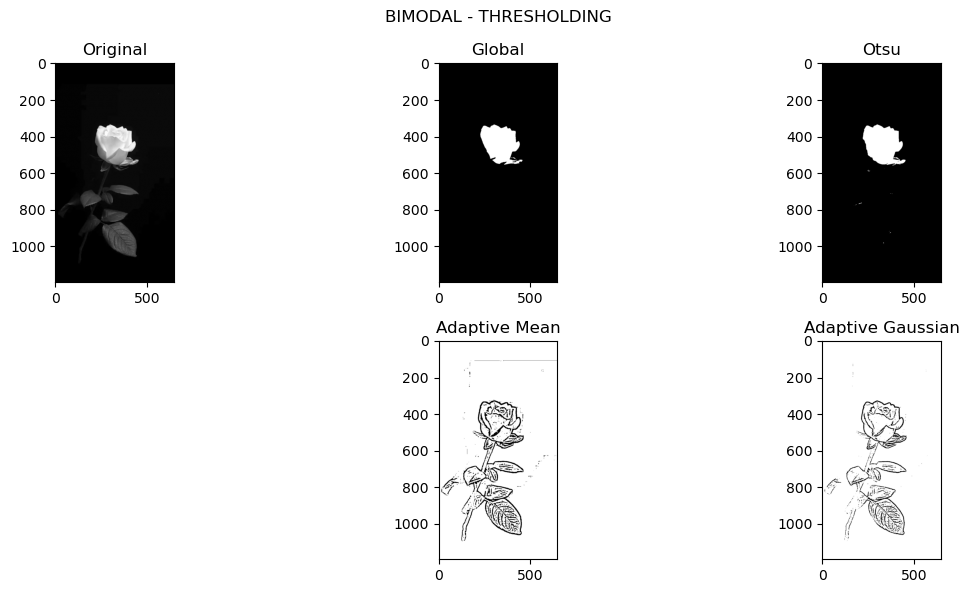

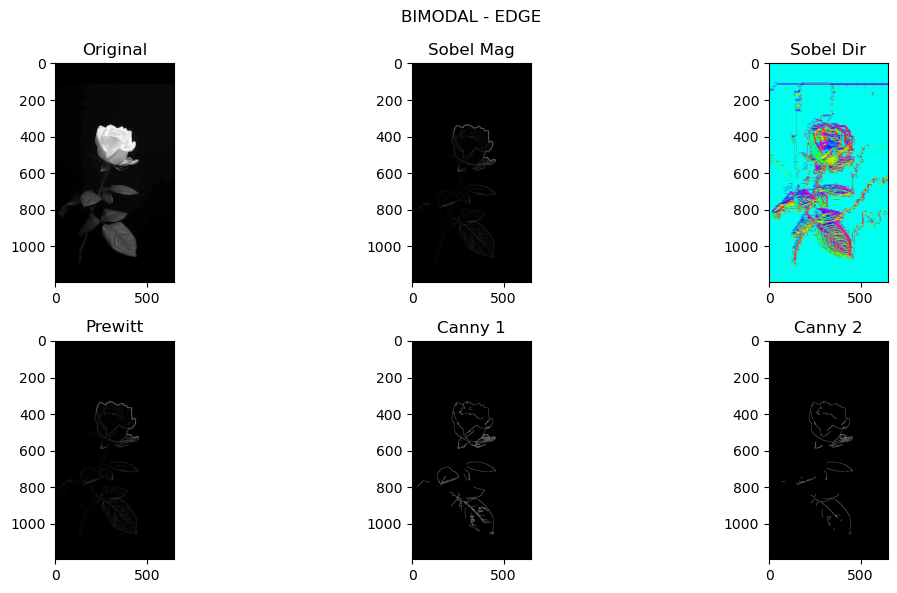

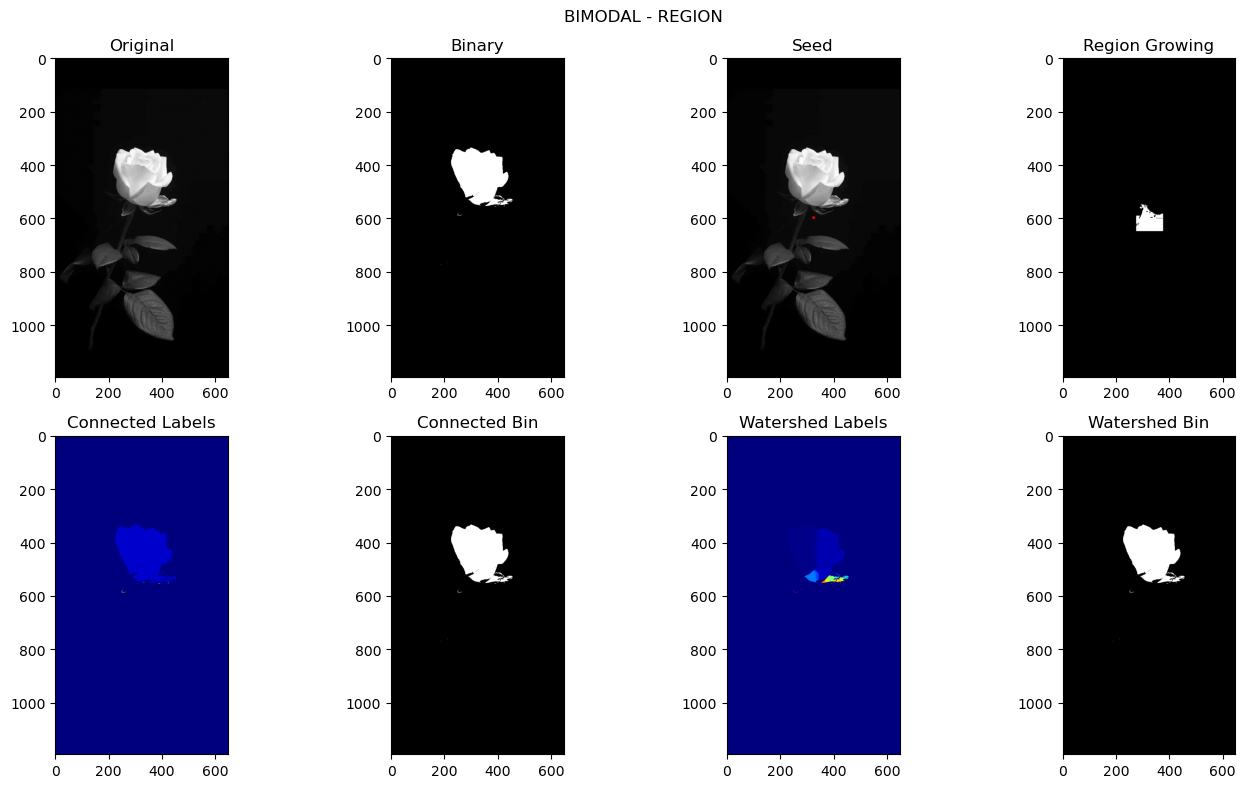


=== UNEVEN ===
Method | IoU | Dice | Acc | Prec | Recall
global       0.438 0.609 0.518 0.879 0.466
otsu         0.490 0.658 0.551 0.853 0.535
adapt_mean   0.848 0.918 0.877 0.997 0.850
adapt_gauss  0.892 0.943 0.910 0.968 0.919
sobel        0.644 0.784 0.652 0.785 0.783
canny_1      0.076 0.141 0.235 0.741 0.078
canny_2      0.055 0.103 0.221 0.719 0.056
connected    0.448 0.619 0.529 0.888 0.475
region_grow  0.017 0.033 0.202 0.718 0.017
watershed    0.448 0.619 0.529 0.888 0.475


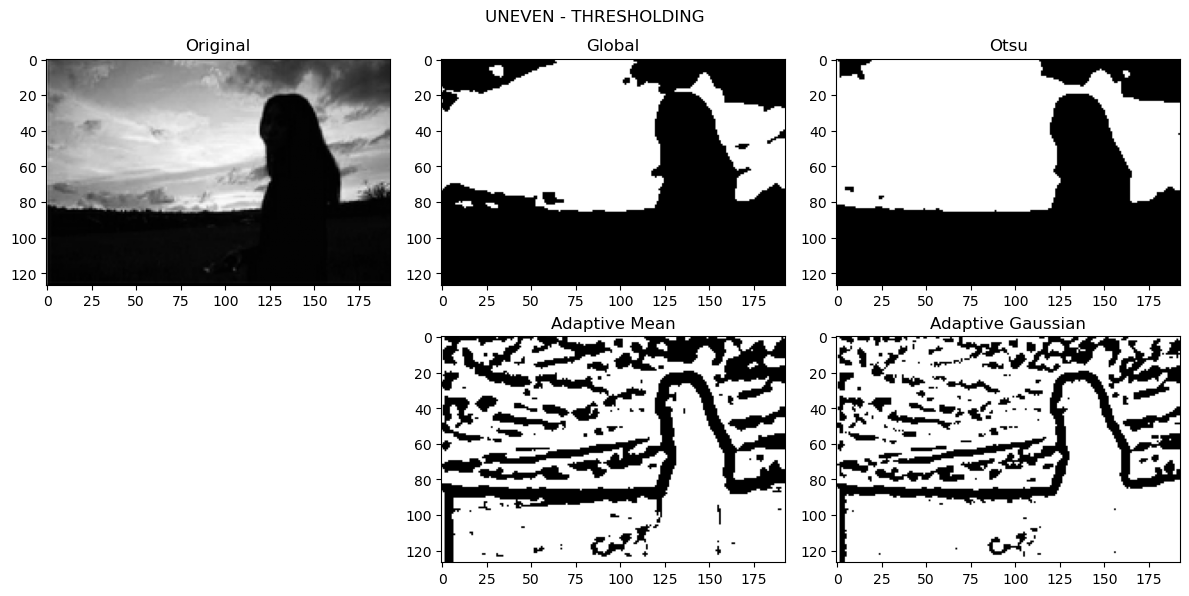

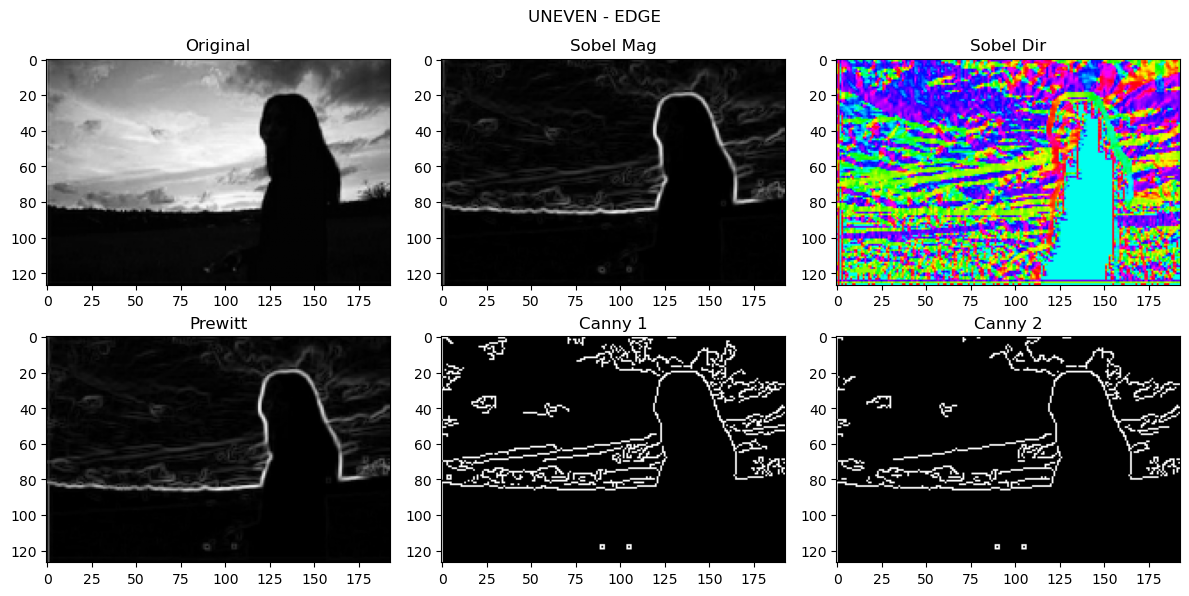

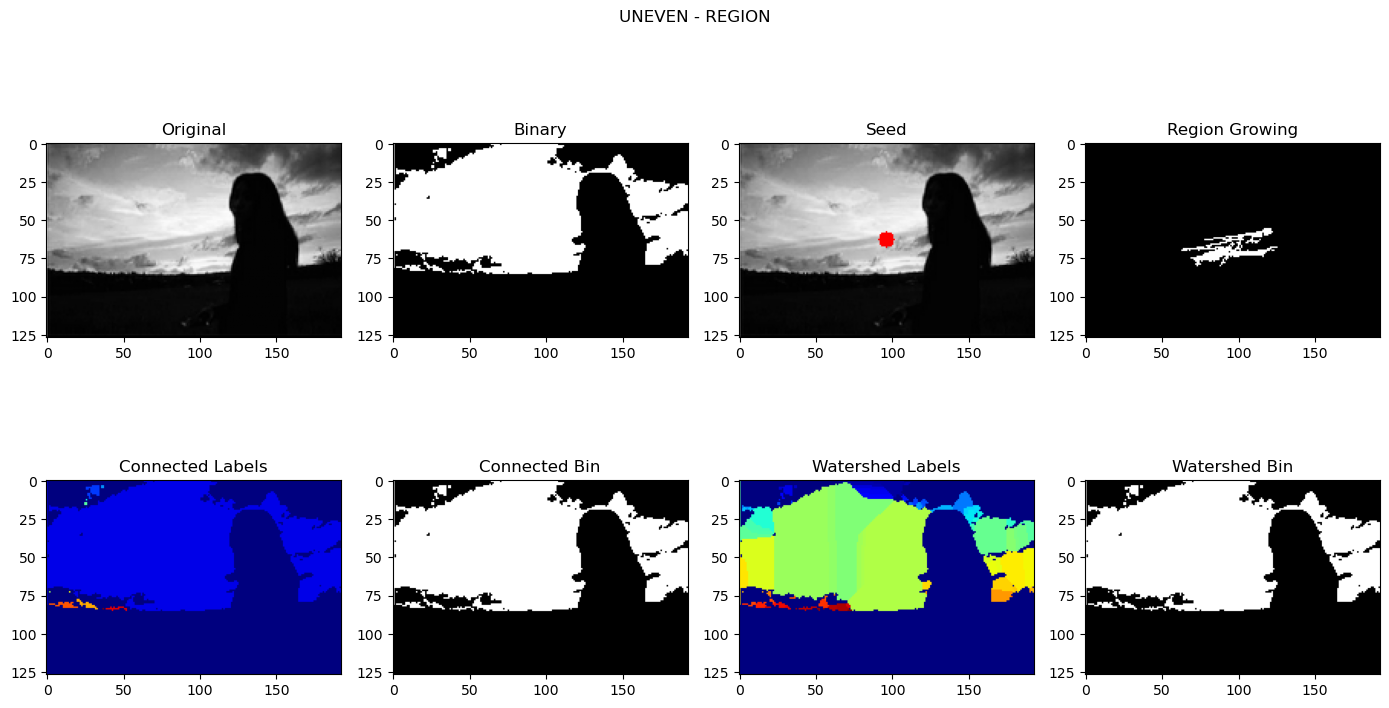


=== OVERLAP ===
Method | IoU | Dice | Acc | Prec | Recall
global       0.941 0.970 0.965 0.941 1.000
otsu         1.000 1.000 1.000 1.000 1.000
adapt_mean   0.619 0.764 0.710 0.703 0.837
adapt_gauss  0.640 0.780 0.714 0.685 0.906
sobel        0.527 0.690 0.529 0.547 0.935
canny_1      0.019 0.037 0.367 0.127 0.022
canny_2      0.018 0.036 0.391 0.161 0.020
connected    0.937 0.968 0.963 0.938 1.000
region_grow  0.000 0.000 0.439 0.000 0.000
watershed    0.937 0.968 0.963 0.938 1.000


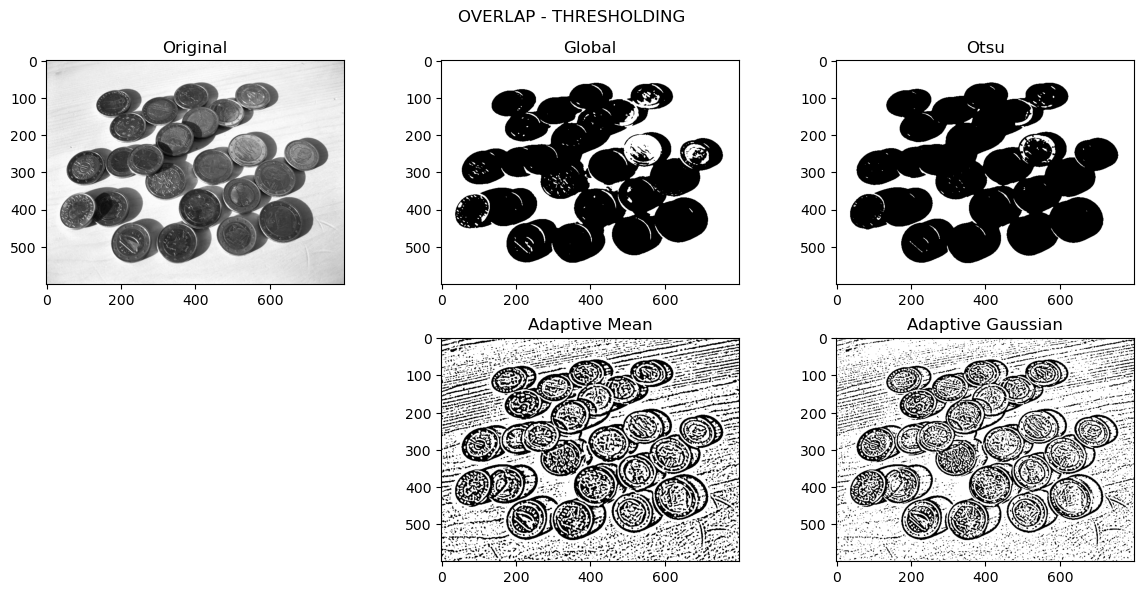

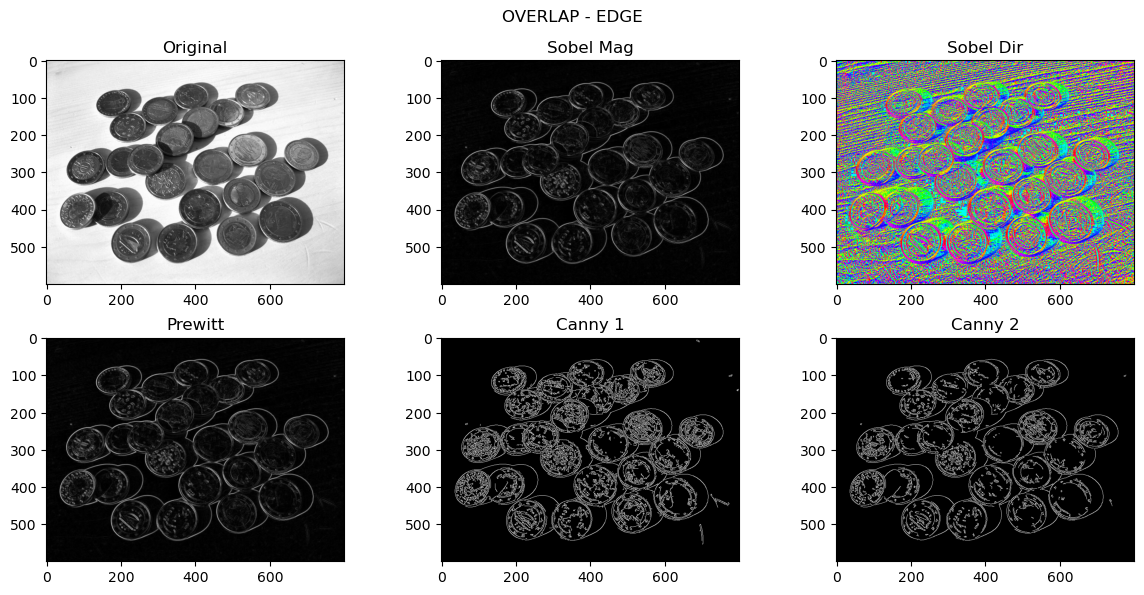

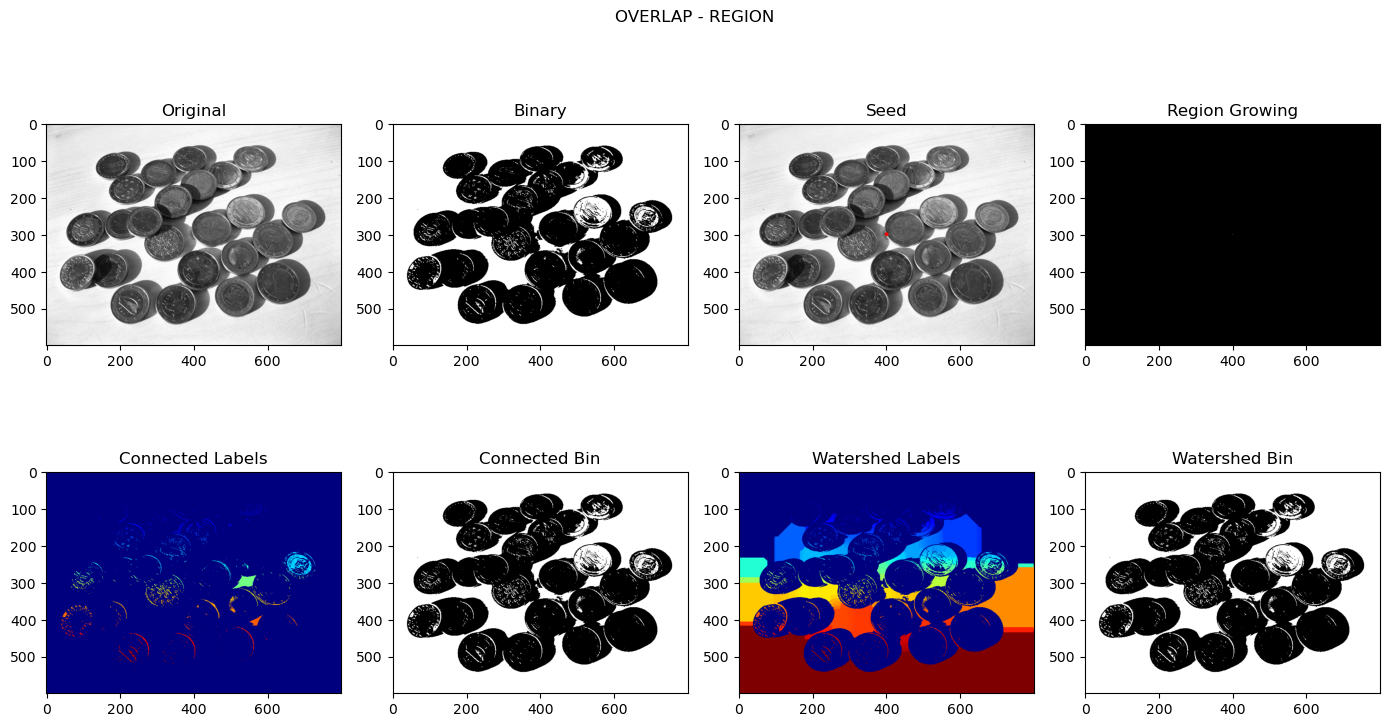

In [8]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from skimage.segmentation import watershed
from skimage.feature import peak_local_max
from scipy import ndimage

# =========================
# SAFE READ
# =========================
def safe_read(path):
    img = cv2.imread(path, 0)
    if img is None:
        raise ValueError(f"Gagal load: {path}")
    return img


# =========================
# AUTO GT GENERATOR
# =========================
def generate_gt(img, mode):
    blur = cv2.GaussianBlur(img, (5,5), 0)

    if mode == "bimodal":
        _, gt = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    elif mode == "uneven":
        gt = cv2.adaptiveThreshold(
            blur, 255,
            cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
            cv2.THRESH_BINARY,
            21, 5
        )

    elif mode == "overlap":
        _, binary = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

        dist = ndimage.distance_transform_edt(binary)
        coords = peak_local_max(dist, footprint=np.ones((3,3)), labels=binary)

        mask = np.zeros(dist.shape, dtype=bool)
        if len(coords) > 0:
            mask[tuple(coords.T)] = True

        markers, _ = ndimage.label(mask)
        labels = watershed(-dist, markers, mask=binary)

        gt = (labels > 0).astype(np.uint8) * 255

    else:
        gt = np.zeros_like(img)

    return gt


# =========================
# LOAD IMAGES
# =========================
def load_images():
    images = {}

    img1 = safe_read("bimodal.jpg")
    img2 = safe_read("uneve.png")   # pastikan nama benar
    img3 = safe_read("overlapping.jpg")

    gt1 = cv2.imread("bimodal_gt.png", 0)
    gt2 = cv2.imread("uneven_gt.png", 0)
    gt3 = cv2.imread("overlap_gt.png", 0)

    if gt1 is None:
        gt1 = generate_gt(img1, "bimodal")
    if gt2 is None:
        gt2 = generate_gt(img2, "uneven")
    if gt3 is None:
        gt3 = generate_gt(img3, "overlap")

    gt1 = (gt1 > 0).astype(np.uint8)*255
    gt2 = (gt2 > 0).astype(np.uint8)*255
    gt3 = (gt3 > 0).astype(np.uint8)*255

    images["bimodal"] = (img1, gt1)
    images["uneven"] = (img2, gt2)
    images["overlap"] = (img3, gt3)

    return images


# =========================
# METRICS
# =========================
def metrics(pred, gt):
    pred = (pred>0).astype(np.uint8)
    gt = (gt>0).astype(np.uint8)

    tp = np.sum((pred==1)&(gt==1))
    fp = np.sum((pred==1)&(gt==0))
    fn = np.sum((pred==0)&(gt==1))
    tn = np.sum((pred==0)&(gt==0))

    iou = tp/(tp+fp+fn+1e-6)
    dice = 2*tp/(2*tp+fp+fn+1e-6)
    acc = (tp+tn)/(tp+tn+fp+fn+1e-6)
    prec = tp/(tp+fp+1e-6)
    rec = tp/(tp+fn+1e-6)

    return iou, dice, acc, prec, rec


# =========================
# THRESHOLDING
# =========================
def thresholding(img):
    blur = cv2.GaussianBlur(img,(5,5),0)
    results = {}

    _, results["global"] = cv2.threshold(blur,127,255,cv2.THRESH_BINARY)
    _, results["otsu"] = cv2.threshold(blur,0,255,cv2.THRESH_BINARY+cv2.THRESH_OTSU)

    results["adapt_mean"] = cv2.adaptiveThreshold(
        blur,255,cv2.ADAPTIVE_THRESH_MEAN_C,cv2.THRESH_BINARY,11,2)

    results["adapt_gauss"] = cv2.adaptiveThreshold(
        blur,255,cv2.ADAPTIVE_THRESH_GAUSSIAN_C,cv2.THRESH_BINARY,11,2)

    return results


# =========================
# EDGE DETECTION
# =========================
def edge_detection(img):
    results = {}

    sobelx = cv2.Sobel(img, cv2.CV_64F,1,0)
    sobely = cv2.Sobel(img, cv2.CV_64F,0,1)

    mag = np.sqrt(sobelx**2 + sobely**2)
    mag = cv2.normalize(mag,None,0,255,cv2.NORM_MINMAX)

    results["sobel"] = mag.astype(np.uint8)

    results["canny_1"] = cv2.Canny(img,50,150)
    results["canny_2"] = cv2.Canny(img,100,200)

    return results


# =========================
# REGION METHODS
# =========================
def region_methods(img):
    results = {}

    _, binary = cv2.threshold(img,127,255,cv2.THRESH_BINARY)

    _, labels = cv2.connectedComponents(binary)
    results["connected"] = (labels>0).astype(np.uint8)*255

    # Region Growing
    seed = (img.shape[0]//2, img.shape[1]//2)
    mask = np.zeros_like(img)
    mask[seed]=1

    for _ in range(50):
        dil = cv2.dilate(mask,np.ones((3,3),np.uint8))
        mask = np.where((dil==1)&(abs(img-img[seed])<20),1,mask)

    results["region_grow"] = mask*255

    # Watershed
    dist = ndimage.distance_transform_edt(binary)
    coords = peak_local_max(dist, footprint=np.ones((3,3)), labels=binary)

    mask_ws = np.zeros(dist.shape, dtype=bool)
    if len(coords)>0:
        mask_ws[tuple(coords.T)] = True

    markers,_ = ndimage.label(mask_ws)
    labels_ws = watershed(-dist, markers, mask=binary)

    results["watershed"] = (labels_ws>0).astype(np.uint8)*255

    return results


# =========================
# MAIN
# =========================
images = load_images()

for name,(img,gt) in images.items():
    print(f"\n=== {name.upper()} ===")

    th = thresholding(img)
    ed = edge_detection(img)
    rg = region_methods(img)

    all_results = {**th, **ed, **rg}

    print("Method | IoU | Dice | Acc | Prec | Recall")
    for k,v in all_results.items():
        iou,dice,acc,prec,rec = metrics(v,gt)
        print(f"{k:12} {iou:.3f} {dice:.3f} {acc:.3f} {prec:.3f} {rec:.3f}")

    # =========================
    # VISUALISASI LENGKAP
    # =========================

    # --- THRESHOLDING ---
    plt.figure(figsize=(12,6))
    plt.suptitle(f"{name.upper()} - THRESHOLDING")

    plt.subplot(2,3,1); plt.imshow(img,cmap='gray'); plt.title("Original")
    plt.subplot(2,3,2); plt.imshow(th["global"],cmap='gray'); plt.title("Global")
    plt.subplot(2,3,3); plt.imshow(th["otsu"],cmap='gray'); plt.title("Otsu")
    plt.subplot(2,3,5); plt.imshow(th["adapt_mean"],cmap='gray'); plt.title("Adaptive Mean")
    plt.subplot(2,3,6); plt.imshow(th["adapt_gauss"],cmap='gray'); plt.title("Adaptive Gaussian")

    plt.tight_layout()
    plt.show()

    # --- EDGE ---
    sobelx = cv2.Sobel(img, cv2.CV_64F,1,0)
    sobely = cv2.Sobel(img, cv2.CV_64F,0,1)
    sobel_dir = np.arctan2(sobely, sobelx)

    # Prewitt
    kx = np.array([[1,1,1],[0,0,0],[-1,-1,-1]])
    ky = np.array([[-1,0,1],[-1,0,1],[-1,0,1]])
    px = cv2.filter2D(img.astype(np.float64), -1, kx)
    py = cv2.filter2D(img.astype(np.float64), -1, ky)
    prewitt = np.sqrt(px**2 + py**2)
    prewitt = cv2.normalize(prewitt,None,0,255,cv2.NORM_MINMAX)

    plt.figure(figsize=(12,6))
    plt.suptitle(f"{name.upper()} - EDGE")

    plt.subplot(2,3,1); plt.imshow(img,cmap='gray'); plt.title("Original")
    plt.subplot(2,3,2); plt.imshow(ed["sobel"],cmap='gray'); plt.title("Sobel Mag")
    plt.subplot(2,3,3); plt.imshow(sobel_dir,cmap='hsv'); plt.title("Sobel Dir")
    plt.subplot(2,3,4); plt.imshow(prewitt,cmap='gray'); plt.title("Prewitt")
    plt.subplot(2,3,5); plt.imshow(ed["canny_1"],cmap='gray'); plt.title("Canny 1")
    plt.subplot(2,3,6); plt.imshow(ed["canny_2"],cmap='gray'); plt.title("Canny 2")

    plt.tight_layout()
    plt.show()

    # --- REGION ---
    _, binary = cv2.threshold(img,127,255,cv2.THRESH_BINARY)

    seed = (img.shape[0]//2, img.shape[1]//2)
    img_seed = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
    cv2.circle(img_seed,(seed[1],seed[0]),5,(255,0,0),-1)

    labels = cv2.connectedComponents((img>127).astype(np.uint8))[1]

    dist = ndimage.distance_transform_edt(binary)
    coords = peak_local_max(dist, footprint=np.ones((3,3)), labels=binary)

    mask_ws = np.zeros(dist.shape, dtype=bool)
    if len(coords)>0:
        mask_ws[tuple(coords.T)] = True

    markers,_ = ndimage.label(mask_ws)
    labels_ws = watershed(-dist, markers, mask=binary)

    plt.figure(figsize=(14,8))
    plt.suptitle(f"{name.upper()} - REGION")

    plt.subplot(2,4,1); plt.imshow(img,cmap='gray'); plt.title("Original")
    plt.subplot(2,4,2); plt.imshow(binary,cmap='gray'); plt.title("Binary")

    plt.subplot(2,4,3); plt.imshow(img_seed); plt.title("Seed")
    plt.subplot(2,4,4); plt.imshow(rg["region_grow"],cmap='gray'); plt.title("Region Growing")

    plt.subplot(2,4,5); plt.imshow(labels,cmap='jet'); plt.title("Connected Labels")
    plt.subplot(2,4,6); plt.imshow(rg["connected"],cmap='gray'); plt.title("Connected Bin")

    plt.subplot(2,4,7); plt.imshow(labels_ws,cmap='jet'); plt.title("Watershed Labels")
    plt.subplot(2,4,8); plt.imshow(rg["watershed"],cmap='gray'); plt.title("Watershed Bin")

    plt.tight_layout()
    plt.show()